# Pachete necesare pentru folosirea acestui Notebook

Vom folosi [scipy](https://scipy.org/), [numpy](https://numpy.org/) și [matplotlib](https://matplotlib.org/).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import datasets, ndimage
# misc.ascent() was removed from SciPy 1.3, so I will use datasets.ascent()
from scipy.fft import dctn, idctn

# Imaginea cu care lucrăm

Vom folosi o imagine din setul de date oferit implicit de către scipy.

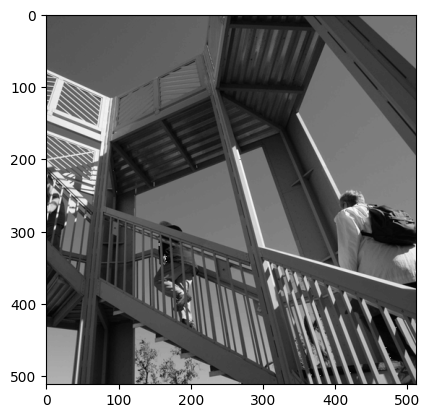

In [3]:
X = datasets.ascent()
plt.imshow(X, cmap = plt.cm.gray)
plt.show()

# Transformata DCT a unei imagini

Transformata DCT se extinde la mai multe dimensiuni similar cu transformata DFT. Pentru un semnal bidimensional, precum o imagine, DCT-II devine:

$$
Y_{m_1,m_2} = \sum_{n_1=0}^{N_1-1}
              \sum_{n_2=0}^{N_2-1}
              x_{n_1,n_2}
              \cos\left[\frac{\pi}{N_1}m_1
                \left(n_1 + \frac12\right)\right]
              \cos\left[\frac{\pi}{N_2}m_2\left(n_2 + \frac12\right)\right]
$$

* unde $n_1$ și $n_2$ sunt pozițile pixelilor pe orizontală, respectiv, pe verticală
* bin-urile rezultate corespund pozițiilor pixelilor
* spectrul este în continuare simetric și par
* proprietățile transformatei DCT-II sunt respectate și în cazul celei 2D

În Python avem rutina `scipy.fft.dct` pentru 1D și `scipy.fft.dctn` pentru generalizarea la semnale $n$-dimensionale. Dimensiunea este determinată automat după forma semnalului; tipul DCT poate fi specificat prin atributul `type` (implicit II).

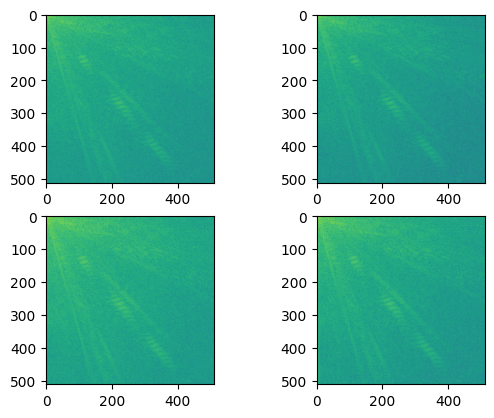

In [4]:
Y1 = dctn(X, type = 1)
Y2 = dctn(X, type = 2)
Y3 = dctn(X, type = 3)
Y4 = dctn(X, type = 4)
freq_db_1 = 20 * np.log10(abs(Y1))
freq_db_2 = 20 * np.log10(abs(Y2))
freq_db_3 = 20 * np.log10(abs(Y3))
freq_db_4 = 20 * np.log10(abs(Y4))

plt.subplot(221).imshow(freq_db_1)
plt.subplot(222).imshow(freq_db_2)
plt.subplot(223).imshow(freq_db_3)
plt.subplot(224).imshow(freq_db_4)
plt.show()

# Compactarea energiei. Compresie.

Putem profita de proprietatea compresiei energiei prin anularea frecvențelor DCT începând cu *bin*-ul `k` după care aplicăm transformata DCT inversă (similar cu tema anterioară):

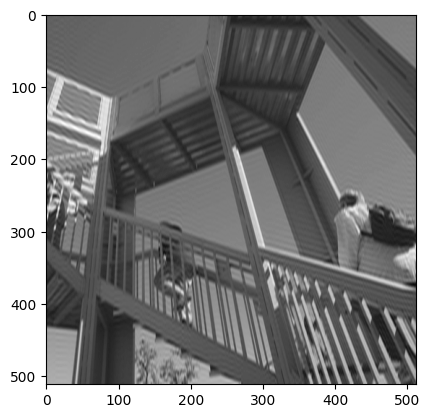

In [5]:
k = 120

Y_ziped = Y2.copy()
Y_ziped[k:] = 0
X_ziped = idctn(Y_ziped)

plt.imshow(X_ziped, cmap = plt.cm.gray)
plt.show()

# JPEG

Algoritmul de compresie JPEG are patru etape:

1. transformarea imaginii din pixeli RGB în Y'CbCr
2. aplicarea 2D-DCT pe blocuri disincte de 8x8 pixeli din imagine
3. cuantizarea în frecvență cu $Q$ dat de standardul JPEG
4. compresia rezultatului cu coduri Huffman

Unde matricea JPEG de cuantizare $Q$ este:
$$
Q =
\begin{bmatrix}
16 & 11 & 10 & 16 & 24 & 40 & 51 & 61 & \\
12 & 12 & 14 & 19 & 26 & 28 & 60 & 55 & \\
14 & 13 & 16 & 24 & 40 & 57 & 69 & 56 & \\
14 & 17 & 22 & 29 & 51 & 87 & 80 & 62 & \\
18 & 22 & 37 & 56 & 68 & 109 & 103 & 77 & \\
24 & 35 & 55 & 64 & 81 & 104 & 113 & 92 & \\
49 & 64 & 78 & 87 & 103 & 121 & 120 & 101\\
72 & 92 & 95 & 98 & 112 & 100 & 103 & 99\\
\end{bmatrix}
$$

Imaginea noastră de test este monocromă, deci nu necesită pasul 1, dar putem efectua o operație de *down-sampling* în preprocesare precum am prezentat la curs.

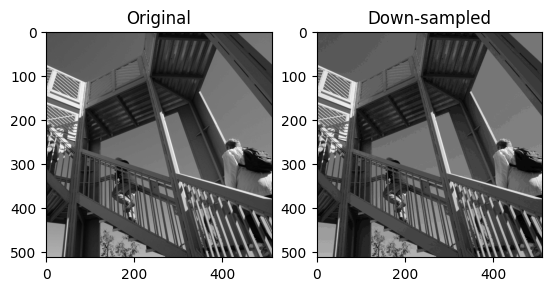

In [6]:
Q_down = 10

X_jpeg = X.copy()
X_jpeg = Q_down * np.round(X_jpeg / Q_down)

plt.subplot(121).imshow(X, cmap = plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(X_jpeg, cmap = plt.cm.gray)
plt.title('Down-sampled')
plt.show()

Pentru fiecare bloc de $8\times 8$ aplică DCT și cuantizare.

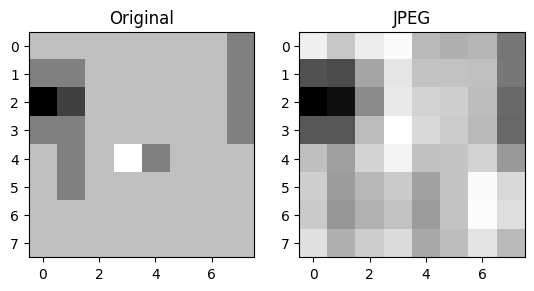

Componente în frecvență:64
Componente în frecvență după cuantizare: 14


In [7]:
Q_jpeg = [[16, 11, 10, 16, 24, 40, 51, 61],
          [12, 12, 14, 19, 26, 28, 60, 55],
          [14, 13, 16, 24, 40, 57, 69, 56],
          [14, 17, 22, 29, 51, 87, 80, 62],
          [18, 22, 37, 56, 68, 109, 103, 77],
          [24, 35, 55, 64, 81, 104, 113, 92],
          [49, 64, 78, 87, 103, 121, 120, 101],
          [72, 92, 95, 98, 112, 100, 103, 99]]

# Encoding
x = X[:8, :8]
y = dctn(x)
y_jpeg = Q_jpeg*np.round(y/Q_jpeg)

# Decoding
x_jpeg = idctn(y_jpeg)

# Results
y_nnz = np.count_nonzero(y)
y_jpeg_nnz = np.count_nonzero(y_jpeg)

plt.subplot(121).imshow(x, cmap = plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(x_jpeg, cmap = plt.cm.gray)
plt.title('JPEG')
plt.show()

print('Componente în frecvență:' + str(y_nnz) + 
      '\nComponente în frecvență după cuantizare: ' + str(y_jpeg_nnz))

# Sarcini

1. [6p] Completați algoritmul JPEG incluzând toate blocurile din imagine.

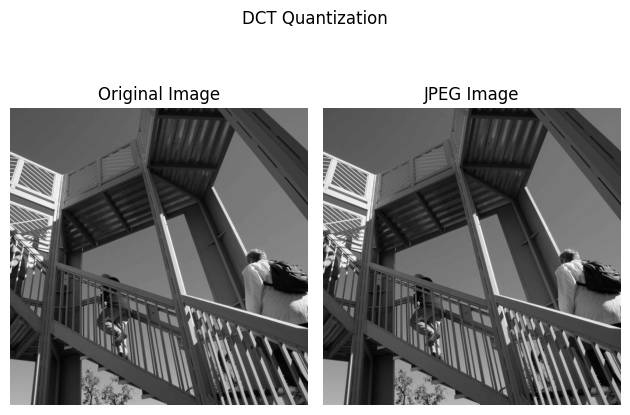

Frequency components = 250422
Frequency components in JPEG = 125029


In [13]:
def greyImageToJPEG(Image, showPlots = True, factor = 1.0):
    Image = Image.astype(np.float32)

    height, width = Image.shape

    JPEG = np.zeros_like(Image, dtype = np.float32)

    originalNonZero = 0
    JPEGNonZero = 0

    Q = factor * np.array(Q_jpeg, dtype = np.float32)

    for i in range(0, height, 8):
        for j in range(0, width, 8):
            currentBlock = Image[i:i + 8, j:j + 8]
        
            currentBlockDCT = dctn(currentBlock)
            originalNonZero += np.count_nonzero(currentBlockDCT)

            currentBlockDCT = Q * np.round(currentBlockDCT / Q)
            JPEGNonZero += np.count_nonzero(currentBlockDCT)

            currentBlockIDCT = idctn(currentBlockDCT)
            JPEG[i:i + 8, j:j + 8] = currentBlockIDCT

    JPEG = np.clip(JPEG, 0, 255)

    if showPlots:
        fig, axs = plt.subplots(1, 2)
        fig.suptitle('DCT Quantization')

        axs[0].imshow(Image.astype(np.uint8), cmap = plt.cm.gray)
        axs[0].set_title('Original Image')
        axs[0].axis('off')

        axs[1].imshow(JPEG.astype(np.uint8), cmap = plt.cm.gray)
        axs[1].set_title('JPEG Image')
        axs[1].axis('off')

        fig.tight_layout()
        fig.savefig('1.pdf')
        plt.show()

        print(f'Frequency components = {originalNonZero}')
        print(f'Frequency components in JPEG = {JPEGNonZero}')

    return JPEG

_ = greyImageToJPEG(X) # _ since I don't want the JPEG array to be printed

2. [4p] Extindeți la imagini color (incluzând transformarea din RGB în Y'CbCr).

In [14]:
def RGBtoYCbCr(Image):
    Image = Image.astype(np.float32)

    red = Image[:, :, 0]
    green = Image[:, :, 1]
    blue = Image[:, :, 2]

    Y = 0.299 * red + 0.587 * green + 0.114 * blue 
    Cb = -0.1687 * red - 0.3313 * green + 0.5 * blue + 128 
    Cr = 0.5 * red - 0.4187 * green - 0.0813 * blue + 128 

    return Y, Cb, Cr

def YCbCrToRGB(Y, Cb, Cr):
    red = Y + 1.402 * (Cr - 128)
    green = Y - 0.34414 * (Cb - 128) - 0.71414 * (Cr - 128)
    blue = Y + 1.772 * (Cb - 128)

    return np.clip(np.stack((red, green, blue), axis = 2), 0, 255)

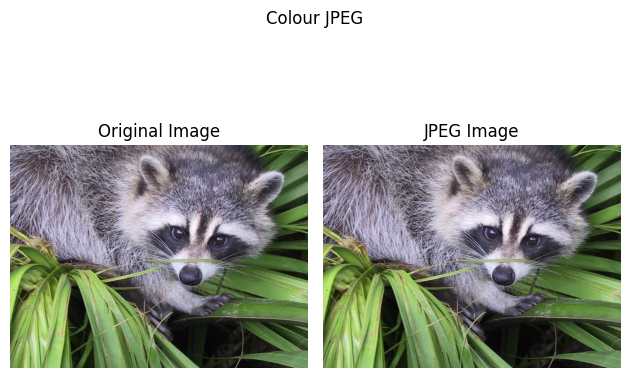

In [15]:
def colourImageToJPEG(Image, showPlots = True, factor = 1.0):
    Y, Cb, Cr = RGBtoYCbCr(Image)

    YJPEG = greyImageToJPEG(Y, False, factor)
    CbJPEG = greyImageToJPEG(Cb, False, factor)
    CrJPEG = greyImageToJPEG(Cr, False, factor)

    JPEG = YCbCrToRGB(YJPEG, CbJPEG, CrJPEG)

    if showPlots:
        fig, axs = plt.subplots(1, 2)
        fig.suptitle('Colour JPEG')

        axs[0].imshow(Image.astype(np.uint8))
        axs[0].set_title('Original Image')
        axs[0].axis('off')

        axs[1].imshow(JPEG.astype(np.uint8))
        axs[1].set_title('JPEG Image')
        axs[1].axis('off')

        fig.tight_layout()
        fig.savefig('2.pdf')
        plt.show()

    return JPEG

cuteRaccoon = datasets.face()
_ = colourImageToJPEG(cuteRaccoon)

3. [6p] Extindeți algoritmul pentru compresia imaginii până la un prag MSE impus de utilizator.

In [16]:
def MSE(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    return np.mean((a - b) ** 2)

def compress(Image, RGB, factor):
    return colourImageToJPEG(Image, showPlots = False, factor = factor) if RGB else greyImageToJPEG(Image, showPlots = False, factor = factor)

def getHigherFactor(Image, RGB, target):
    high = 1.0
    highJPEG = compress(Image, RGB, high)
    highMSE = MSE(highJPEG, Image)

    while highMSE <= target:
        high *= 2.0
        highJPEG = compress(Image, RGB, high)
        highMSE = MSE(highJPEG, Image)

    return high


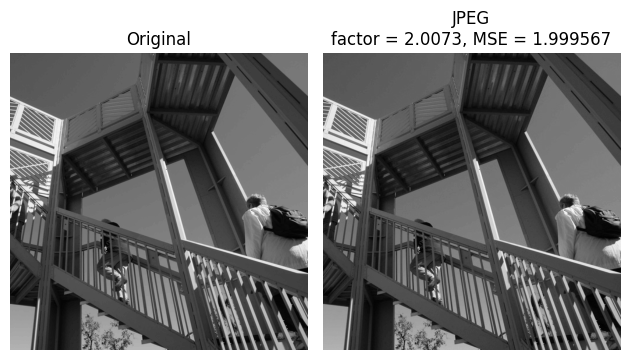

Factor = 2.0073342285156253, MSE = 1.9995665550231934


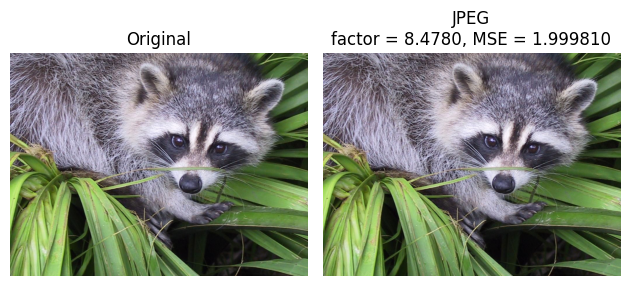

Factor = 8.478009216308592, MSE = 1.9998095035552979


In [20]:
def compressJPEGToTargetMSE(Image, targetMSE, RGB = False, showPlots = True, tolerance = 1e-3, maxIterations = 30):
    Image = Image.astype(np.float32)

    low = 0.001
    lowJPEG = compress(Image, RGB, low)
    lowMSE = MSE(lowJPEG, Image)

    high = getHigherFactor(Image, RGB, targetMSE)

    bestFactor = low 
    bestJPEG = lowJPEG
    bestMSE = lowMSE

    iteration = 0
    while high - low > tolerance:
        if iteration >= maxIterations:
            break

        middle = low + (high - low) / 2
        middleJPEG = compress(Image, RGB, middle)
        middleMSE = MSE(middleJPEG, Image)

        if middleMSE <= targetMSE:
            bestFactor = middle 
            bestJPEG = middleJPEG
            bestMSE = middleMSE 
            low = middle 
        else:
            high = middle 

        iteration += 1

    if showPlots:
        fig, axs = plt.subplots(1, 2)

        if not RGB:
            axs[0].imshow(Image.astype(np.uint8), cmap = plt.cm.gray)
        else:
            axs[0].imshow(Image.astype(np.uint8))
        axs[0].set_title('Original')
        axs[0].axis('off')

        if not RGB:
            axs[1].imshow(bestJPEG.astype(np.uint8), cmap = plt.cm.gray)
        else:
            axs[1].imshow(bestJPEG.astype(np.uint8))
        axs[1].set_title(f'JPEG\nfactor = {bestFactor:.4f}, MSE = {bestMSE:.6f}')
        axs[1].axis('off')
        
        fig.tight_layout()
        fig.savefig('3.pdf')
        plt.show()
    
    return bestJPEG, bestFactor, bestMSE

JPEG, factor, MSEValue = compressJPEGToTargetMSE(X, targetMSE = 2)
print(f'Factor = {factor}, MSE = {MSEValue}')

JPEG, factor, MSEValue = compressJPEGToTargetMSE(cuteRaccoon, targetMSE = 2, RGB = True)
print(f'Factor = {factor}, MSE = {MSEValue}')


4. [4p] Extindeți algoritmul pentru compresie video. Demonstrați pe un clip scurt din care luați fiecare cadru și îl tratați ca pe o imagine.

In [ ]:
import imageio.v2 as imageio

def compressVideoToJPEG(inputPath, outputPath):
    reader = imageio.get_reader(inputPath)
    fps = reader.get_meta_data().get('fps', 25)

    i = 0
    compressedFrames = []
    for frame in reader:
        i += 1
        print(i)
        compressedFrames.append(colourImageToJPEG(frame, False, 100))
    reader.close()

    print(len(compressedFrames))

    writer = imageio.get_writer(outputPath, fps = fps)
    for frame in compressedFrames:
        writer.append_data(frame)
    writer.close()

compressVideoToJPEG('input.mp4', 'outputJPEG.mp4')

1


C:\Users\Andu\AppData\Local\Temp\ipykernel_23632\2010397664.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Y = 0.299 * red + 0.587 * green + 0.114 * blue
C:\Users\Andu\AppData\Local\Temp\ipykernel_23632\2010397664.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Cb = -0.1687 * red - 0.3313 * green + 0.5 * blue + 128
C:\Users\Andu\AppData\Local\Temp\ipykernel_23632\2010397664.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Cr = 0.5 * red - 0.4187 * green - 0.0813 * blue + 128
C:\Users\Andu\AppData\Local\Temp\ipykernel_23632\2010397664.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  red = Y + 1.402 * (Cr - 12

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
